이썬 머신러닝 완벽 가이드
ch9. 7~9 (pg.625-647)

## 07. 행렬 분해를 이용한 잠재 요인 협업 필터링 실습



행렬 분해 잠재 요인 협업 필터링은 SVD나 NMF등을 적용할 수 있는데, 일반적으로 행렬 분해에는 SVD가 자주 사용되지만 사용자 - 아이템 평점 행렬에는 사용자가 평점을 매기지 않은 NULL데이터가 많기 때문에 주로 SGD나 ALS기반의 행렬 분해를 이용한다.

확률적 경사 하강법을 이용한 행렬 분해 예제의 get_mse() 함수를 그대로 사용하고 행렬 분해로직을 새로운 matrix_factorization() 함수로 정리한다. matrix_factorization(R,K,learning_rate=0.01, r_lambda=0.01)에서 R은 원본 사용자-아이템 평점 행렬이며, K는 잠재 요인의 차원 수, steps는 SGD의 반복 횟수, learning_rate는 학습룰, r_lambda는 L2규제 계수이다.

In [ ]:
import numpy as np

def get_rmse(R, P, Q, non_zeros):
  error=0
  for i,j,r in non_zeros:
    pred= np.dot(P[i,:],Q[j,:].T)
    error+=pow(r-pred,2)
  rmse = np.sqrt(error/len(non_zeros))
  return rmse

In [ ]:
def matrix_factorization(R, K, steps=200, learning_rate=0.01, r_lambda=0.01):
  num_users,num_items=R.shape
  #Q와 P매트릭스의 크기를 지정하고 정규 분포를 가진 랜덤한 값으로 입력한다.
  np.random.seed(1)
  P = np.random.normal(scale=1./K, size=(num_users,K))
  Q = np.random.normal(scale=1./K, size=(num_items,K))


  #R>0인 행 위치, 열 위치, 값을 non_zeros 리스트 객체에 저장
  non_zeros=[(i,j,R[i,j]) for i in range(num_users) for j in range(num_items) if R[i,j]>0]

  #SGD 기법으로 P와 Q 매트릭스를 계속 업데이트
  for step in range(steps):
    for i,j,r in non_zeros:
      #실제 값과 예측 값의 차이인 오류 값 구함
      eij = r-np.dot(P[i,:],Q[j,:].T)
      #Regulation을 반영한 SGD업데이트 공식 적용
      P[i,:]= P[i,:]+learning_rate*(eij*Q[j,:]-r_lambda*P[i,:])
      Q[j,:]= Q[j,:]+learning_rate*(eij*P[i,:]-r_lambda*Q[j,:])

    rmse = get_rmse(R, P, Q, non_zeros)
    if (step%10)==0:
      print("### iteration step : ", step, " rmse : ", rmse)

  return P, Q

In [ ]:
import pandas as pd
import numpy as np

movies = pd.read_csv('/content/drive/MyDrive/data/movies.csv')
ratings = pd.read_csv('/content/drive/MyDrive/data/ratings.csv')
ratings = ratings[['userId','movieId','rating']]
ratings_matrix = ratings.pivot_table ('rating', index='userId',columns='movieId')

#title칼럼을 얻기 위해 movies와 조인 수행
ratings_movies = pd.merge(ratings, movies, on='movieId')

#columns='title'로 title칼럼으로 피벗 수행
ratings_matrix = ratings_movies.pivot_table('rating', index='userId', columns='title')

만들어진 사용자-아이템 평점 행렬을 matrix_factorization()함수를 이용해 행렬 분해한다. 수행시간이 오래 걸리므로 SGD 반복 횟수인 steps는 200회만 지정한다.

In [ ]:
P, Q = matrix_factorization(ratings_matrix.values, K=50, steps=200, learning_rate=0.01, r_lambda=0.01)
pred_matrix = np.dot(P,Q.T)

### iteration step :  0  rmse :  2.9023619751337115
### iteration step :  10  rmse :  0.7335768591017939
### iteration step :  20  rmse :  0.5115539026853438
### iteration step :  30  rmse :  0.37261628282537734
### iteration step :  40  rmse :  0.29608182991810145
### iteration step :  50  rmse :  0.2520353192341621
### iteration step :  60  rmse :  0.22487503275269882
### iteration step :  70  rmse :  0.20685455302331512
### iteration step :  80  rmse :  0.19413418783028674
### iteration step :  90  rmse :  0.1847008200272031
### iteration step :  100  rmse :  0.17742927527209082
### iteration step :  110  rmse :  0.17165226964707506
### iteration step :  120  rmse :  0.16695181946871496
### iteration step :  130  rmse :  0.16305292191997453
### iteration step :  140  rmse :  0.159766919296796
### iteration step :  150  rmse :  0.15695986999457337
### iteration step :  160  rmse :  0.15453398186715442
### iteration step :  170  rmse :  0.1524161855107769
### iteration step :  180  rm

In [ ]:
ratings_pred_matrix = pd.DataFrame(data=pred_matrix, index=ratings_matrix.index, columns=ratings_matrix.columns)
ratings_pred_matrix.head(3)

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,3.055084,4.092018,3.564130,4.502167,3.981215,1.271694,3.603274,2.333266,5.091749,3.972454,...,1.402608,4.208382,3.705957,2.720514,2.787331,3.475076,3.253458,2.161087,4.010495,0.859474
2,3.170119,3.657992,3.308707,4.166521,4.311890,1.275469,4.237972,1.900366,3.392859,3.647421,...,0.973811,3.528264,3.361532,2.672535,2.404456,4.232789,2.911602,1.634576,4.135735,0.725684
3,2.307073,1.658853,1.443538,2.208859,2.229486,0.780760,1.997043,0.924908,2.970700,2.551446,...,0.520354,1.709494,2.281596,1.782833,1.635173,1.323276,2.887580,1.042618,2.293890,0.396941


In [ ]:
#사용자 9번 영화 추천
def get_unseen_movies(ratings_matrix, userId):
  #userId로 입력받은 사용자의 모든 영화 정보를 추출해 Series로 반환함.
  #반환된 user_rating은 영화명을 인덱스로 가지는 Series 객체이다.
  user_rating = ratings_matrix.loc[userId,:]

  #user_rating이 0보다 크면 기존에 관람한 영화. 대상 인덱스를 추출해 list 객체로 만듦
  already_seen = user_rating[user_rating>0].index.tolist()

  #모든 영화명을 list객체로 만듦
  movies_list = ratings_matrix.columns.tolist()

  #list comprehension으로 already_seen에 해당하는 영화는 movies_list에서 제외함.
  unseen_list = [movie for movie in movies_list if movie not in already_seen]

  return unseen_list

def recomm_movie_by_userid(pred_df, userId, unseen_list, top_n=10):
  #예측 평점 DataFrame에서 사용자 id인덱스와 unseen_list로 들어온 영화명 칼럼을 추출해 가장 예측 평점이 높은 순으로 정렬

  recomm_movies = pred_df.loc[userId, unseen_list].sort_values(ascending=False)[:top_n]
  return recomm_movies

In [ ]:
#사용자가 관람하지 않은 영화명 추출
unseen_list = get_unseen_movies(ratings_matrix,9)

#잠재 요인 협업 필터링으로 영화 추천
recomm_movies = recomm_movie_by_userid(ratings_pred_matrix, 9, unseen_list, top_n=10)

#평점 데이터를 DataFrame으로 생성
recomm_movies = pd.DataFrame(data=recomm_movies.values, index=recomm_movies.index, columns=['pred_score'])
recomm_movies

,pred_score
title,
Rear Window (1954),5.704612
"South Park: Bigger, Longer and Uncut (1999)",5.451100
Rounders (1998),5.298393
Blade Runner (1982),5.244951
Roger & Me (1989),5.191962
Gattaca (1997),5.183179
Ben-Hur (1959),5.130463
Rosencrantz and Guildenstern Are Dead (1990),5.087375
"Big Lebowski, The (1998)",5.038690


## 08. 파이썬 추천 시스템 패키지

**Surprise패키지**

파이썬 기반의 춴 시스템 구축을 위한 전용 패키지 중의 하나

In [ ]:
pip install scikit-surprise

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 18.2 MB/s eta 0:00:00


예제는 추천 데이터를 학습용과 테스트용 데이터 세트로 분리한 뒤 SVD 행렬 분해를 통해 잠재 요인 협업 필터링을 수행한다.

In [ ]:
from surprise import SVD
from surprise import Dataset
from surprise import accuracy
from surprise.model_selection import train_test_split

In [12]:
!pip uninstall numpy -y
!pip install numpy==1.26.6
!pip install scikit-surprise --upgrade --no-deps

Found existing installation: numpy 2.1.3
Uninstalling numpy-2.1.3:
  Successfully uninstalled numpy-2.1.3
ERROR: Ignored the following yanked versions: 2.4.0
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11; 1.26.0 Requires-Python <3.13,>=3.9; 1.26.1 Requires-Python <3.13,>=3.9
ERROR: Could not find a version that satisfies the requirement numpy==1.26.6 (from versions: 1.3.0, 1.4.1, 1.5.0, 1.5.1, 1.6.0, 1.6.1, 1.6.2, 1.7.0, 1.7.1, 1.7.2, 1.8.0, 1.8.1, 1.8.2, 1.9.0, 1.9.1, 1.9.2, 1.9.3, 1.10.0.post2, 1.10.1, 1.10.2, 1.10.4, 1.11.0, 1.11.1, 1.11.2, 1.11.3, 1.12.0, 1.12.1, 1.13.0, 1.13.1, 1.13.3, 1.14.0, 1.14.1, 1.14.2, 1.14.3, 1.14.4, 1.14.5, 1.14.6, 1.15.0, 1.15.1, 1.15.2, 1.15.3, 1.15.4, 1.16.0, 1.16.1, 1.16.2, 1.16.3, 1.16.4, 1.16.5, 1.16.6, 1.17.0, 1.17.1, 1.17.2, 1.17.3, 1.17.4

In [14]:
data = Dataset.load_builtin('ml-100k')
#수행 시마다 동일하게 데이터를 분할하기 위해 random_state값 부여
trainset, testset = train_test_split(data, test_size=.25, random_state=0)

Dataset ml-100k could not be found. Do you want to download it? [Y/n] Y
Trying to download dataset from https://files.grouplens.org/datasets/movielens/ml-100k.zip...
Done! Dataset ml-100k has been saved to /root/.surprise_data/ml-100k


무비렌즈 사이트에서 직접 내려받은 movies.csv, ratings.csv는 최근 영화에 대한 평점 정보를 가지고 있지만, Surprise가 내려받은 ml-100k, ml-1m은 과거 버전의 데이터 세트이다. 최신 데이터 세트인 ratings.csv의 경우 칼럼 분리 문자가 콤마(,)인 csv 파일이지만, 과거 버전의 데이터 파일은 분리 문자가 \t문자 이다.

In [17]:
algo = SVD(random_state=0)
algo.fit(trainset)

In [18]:
predictions = algo.test(testset)
print('prediction type:', type(predictions), 'size', len(predictions))
print('prediction 결과의 최초 5개 추출')
predictions[:5]

prediction type: <class 'list'> size 25000
prediction 결과의 최초 5개 추출


[Prediction(uid='120', iid='282', r_ui=4.0, est=np.float64(3.5114147666251547), details={'was_impossible': False}),
 Prediction(uid='882', iid='291', r_ui=4.0, est=np.float64(3.573872419581491), details={'was_impossible': False}),
 Prediction(uid='535', iid='507', r_ui=5.0, est=np.float64(4.033583485472447), details={'was_impossible': False}),
 Prediction(uid='697', iid='244', r_ui=5.0, est=np.float64(3.8463639495936905), details={'was_impossible': False}),
 Prediction(uid='751', iid='385', r_ui=4.0, est=np.float64(3.1807542478219157), details={'was_impossible': False})]

In [19]:
[(pred.uid, pred.iid, pred.est) for pred in predictions[:3]]

[('120', '282', np.float64(3.5114147666251547)),
 ('882', '291', np.float64(3.573872419581491)),
 ('535', '507', np.float64(4.033583485472447))]

이번에는 Surprise 패키지의 다른 추천 예측 메서드인 predict()를 이용해 추천 예측을 해볼 것이다.

predict()는 개별 사용자의 아이템에 대한 추천 평점을 예측해준다.

인자로 개별 사용자 아이디, 아이템 아이디를 입력하면 추천 예측 평점을 포함한 정보를 반환한다.

In [20]:
#사용자 아이디, 아이템 아이디는 문자열로 입력해야 한다.
uid = str(196)
iid = str(302)
pred = algo.predict(uid, iid)
print(pred)

user: 196        item: 302        r_ui = None   est = 4.49   {'was_impossible': False}


In [21]:
accuracy.rmse(predictions)

RMSE: 0.9467


np.float64(0.9466860806937948)

### Surprise 주요 모듈 소개

**Dataset**
Surprise는 user_id, item_id, rating 데이터가 로우 레벨로 된 데이터 세트만 적용할 수 있다.

```Dataset.load_builtin(name='ml-100k')```

```Dataset.load_from_df(df, reader)```

```Dataset.load_from_df(df, reader)```

In [22]:
import pandas as pd

ratings = pd.read_csv('/content/drive/MyDrive/data/ratings.csv')
#ratings_noh.csv 파일로 업로드 시 인덱스와 헤더를 모두 제거한 새로운 파일 생성
ratings.to_csv('/content/drive/MyDrive/data/ratings_noh.csv', index=False, header=False)

새롭게 생성된 ratings_noh.csv 파일은 ratings.csv파일에서 헤더가 삭제된 파일이다.

In [23]:
from surprise import Reader

reader = Reader(line_format = 'user item rating timestamp', sep=',', rating_scale=(0.5,5))
data = Dataset.load_from_file('/content/drive/MyDrive/data/ratings_noh.csv', reader=reader)

Reader 클래스의 주요 생성 파라미터

- line_format(string): 칼럼을 순서대로 나열, 입력된 문자열을 공백으로 분리해 칼럼으로 인식
- sep(char): 칼럼을 분리하는 분리자이며, 디폴트는  \t이다. 판다스 DataFrame에서 입력받을 경우에는 기재할 필요가 없다.
- rating_scale(tuple, optional): 평점값의 최소~최대 평점을 설정. 디폴트는 (1,5)이지만 ratinfs.csv파일의 경우 최송 평점이 0.5ㅡ 최대 평점이 5이므로 (0.5, 5)로 설정

**이제 SVD 행렬 분해 기법을 이용해 추천 예측**

잠재 요인 크기 K값을 나타내는 파라미터인 n_factors를 50으로 설정해 데이터를 학습한 후 테스트 데이터 세트를 적용해 예측 평점을 구한다.

In [24]:
trainset, testset = train_test_split(data, test_size=25, random_state=0)

#수행 시마다 동일한 결과를 도출하기 위해 random_state 설정
algo = SVD(n_factors=50, random_state=0)

#학습 데이터 세트로 학습하고 나서 테스트 데이터 세트로 평점 예측 후 RMSE 평가
algo.fit(trainset)
predictions = algo.test(testset)
accuracy.rmse(predictions)

RMSE: 0.7940


np.float64(0.7939608260279409)

**판다스 DataFrame에서 Surprise 데이터 세트로 로딩**
Dataset.load_from_df()를 이용하면 판다스의 DataFrame에서도 Surprise 데이터 세트로 로딩할 수 있다.

주의할 점: DataFrame 역시 사용자 아이디, 아이템 아이디, 평점 칼럼 순서를 지켜야 한다.

In [25]:
import pandas as pd
from surprise import Reader, Dataset

ratings = pd.read_csv('/content/drive/MyDrive/data/ratings.csv')
reader = Reader(rating_scale=(0.5,5.0))

#ratings DataFrame에서 칼럼은 사용자 아이디, 아이템 아이디, 평점 순서를 지켜야 한다.
data = Dataset.load_from_df(ratings[['userId','movieId','rating']], reader)
trainset, testset = train_test_split(data, test_size=.25, random_state=0)

algo = SVD(n_factors=50, random_state=0)
algo.fit(trainset)
predictions = algo.test(testset)
accuracy.rmse(predictions)

RMSE: 0.8682


np.float64(0.8681952927143516)

### Surprise 추천 알고리즘 클래스

- SVD: 행렬 분해를 통한 잠재 요인 협업 필터링을 위한 SVD 알고리즘
- KNN Basic: 최근접 이웃 협업 필터링을 위한 KNN 알고리즘
- BaselineOnly: 사용자 Bias와 아이템 Bias를 감안한 SGD 베이스라인 알고리즘

* 사용자 예측 Rating: $\hat{r}_{ui} = \mu + b_u + b_i + q_i^T p_u$

* Regularization을 적용한 비용 함수: $\sum (r_{ui} - \hat{r}_{ui})^2 + \lambda (b_i^2 + b_u^2 + \|q_i\|2 + \|p_u\|2)$

**파라미터 명**
- n_factors: 잠재요인 K의 개수, 디폴트는 100, 커질수록 정확도가 높아질 수 있으나 과적합 문제가 발생할 수 있음

- n_epochs: SGD 수행시 반복 횟수. 디폴트는 20
- biased(bool): 베이스라인 사용자 편향 적용 여부, 디폴트 True

###베이스라인 평점

개인의 성향을 반영해 아이템 평가에 편향성 요소를 반영하여 평점을 부과하는 것을 베이스라인 평점이라고 한다.

- $전체 평균 평점 = 모든 사용자의 아이템에 대한 평점을 평균한 값$
- $사용자 편향 점수 = 사용자별 아이템 평점 평균 값 - 전체 평균 평점$
- $아이템 편향 점수 = 아이템별 평점 평균 값 - 전체 평균 평점$

### 교차검증과 하이퍼 파라미터 튜닝

In [27]:
from surprise.model_selection import cross_validate

#판다스 DataFrame에서 Surprise 데이터 세트로 데이터 로딩
ratings = pd.read_csv('/content/drive/MyDrive/data/ratings.csv') #reading data in pandas df
reader = Reader(rating_scale=(0.5,5.0))
data = Dataset.load_from_df(ratings[['userId','movieId','rating']], reader)

algo = SVD(random_state=0)
cross_validate(algo, data, measures=['RMSE','MAE'], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8688  0.8809  0.8679  0.8758  0.8726  0.8732  0.0048  
MAE (testset)     0.6697  0.6765  0.6686  0.6715  0.6695  0.6712  0.0028  
Fit time          0.88    0.94    0.95    1.00    2.18    1.19    0.50    
Test time         0.07    0.22    0.08    0.12    0.19    0.14    0.06    


{'test_rmse': array([0.86875695, 0.88092589, 0.86790862, 0.87578182, 0.87258328]),
 'test_mae': array([0.66974362, 0.67645239, 0.66859186, 0.67147973, 0.6695167 ]),
 'fit_time': (0.8829078674316406,
  0.9437038898468018,
  0.9509680271148682,
  0.9959003925323486,
  2.1785755157470703),
 'test_time': (0.07119917869567871,
  0.22452282905578613,
  0.08252286911010742,
  0.12093091011047363,
  0.18715620040893555)}

cross_validate()는 위의 출력 결과와 같이 폴드별 성능 평가 수치와 전체 폴드의 평균 성능 평가 수치를 함께 보여준다.

Surprise의 GridSearchCV도 사이킷런의 GridSearchCV와 유사하게 교차 검증을 통한 하이퍼 파라미터 최적화를 수행한다. 하이퍼 파라미터 최적화는 알고리즘 유형에 따라 다를 수 있지만, SVD의 경우 주로 점진적 하강 방식의 반복 횟수를 지정하는 n_epochs와 잠재요인K의 크기를 지정하는 n_factors를 튜닝한다.

In [28]:
from ast import Param
from surprise.model_selection import GridSearchCV

#최적화할 파라미터를 딕셔너리 형태로 지정
param_grid = {'n_epochs':[20,40,60], 'n_factors':[50,100,200]}

#CV를 3개 폴드 세트로 지정, 성능 평가는 rmse, mse로 수행하도록 GridSearchCV 구성
gs = GridSearchCV(SVD, param_grid, measures = ['rmse','mae'], cv=3)
gs.fit(data)

#최고 RMSE Evaluation 점수와 그 때의 하이퍼 파라미터
print(gs.best_score['rmse'])
print(gs.best_params['rmse'])

0.8776388808022743
{'n_epochs': 20, 'n_factors': 50}


### Surprise를 이용한 개인화 영화 추천 시스템 구축

Surprise를 이용해 잠재 요인 협업 필터링 기반의 개인화된 영화 추천을 구현한다.

이제는 Surprise패키지로 학습된 추천 알고리즘을 기반으로 특정 사용자가 아직 평점을 매기지 않은 영화 중에서 개인 취향에 가장 적절한 영화를 추천할 것이다.

In [30]:
#다음 코드는 train_test_split()으로 분리되지 않는 데이터 세트에 fit()을 호출해 오류가 발생한다.
#data = Dataset.load_from_df(ratings[['userId','movieId','rating']],reader)
#algo = SVD(n_factors=50, random_state=0)
#algo.fit(data)

데이터 세트 전체를 학습 데이터로 사용하려면 DatasetAutoFolds 클래스를 이용하면 된다.

In [32]:
from surprise.dataset import DatasetAutoFolds

reader = Reader(line_format='user item rating timestamp', sep=',', rating_scale=(0.5,5))
#DatasetAutoFolds 클래스를 ratings_noh.csv 파일 기반으로 생성
data_folds=DatasetAutoFolds(ratings_file='/content/drive/MyDrive/data/ratings_noh.csv', reader=reader)

#전체 데이터를 학습 데이터로 생성함
trainset = data_folds.build_full_trainset()

먼저 SVD를 이용해 학습을 수행한다.

In [33]:
algo = SVD(n_epochs=20, n_factors=50, random_state=0)
algo.fit(trainset)

특정 사용자는 userId=9인 사용자로 지정

Surprise의 API를 이용해 예제를 수행하기 위해 userId 9가 아직 평점을 매기지 않은 영화를 movieId 42로 선정한 뒤 예측 평점을 계산

In [34]:
#영화에 대한 상세 속정 정보 DataFrame 로딩
movies=pd.read_csv('/content/drive/MyDrive/data/movies.csv')

#userId=9의 movieId 데이터를 추출해 movieId=42 데이터가 있는지 확인
movieIds = ratings[ratings['userId']==9]['movieId']
if movieIds[movieIds==42].count() ==0:
  print('사용자 아이디 9는 영화 아이디 42의 평점 없음')

print(movies[movies['movieId']==42])

사용자 아이디 9는 영화 아이디 42의 평점 없음
    movieId                   title              genres
38       42  Dead Presidents (1995)  Action|Crime|Drama


이 movieId 42인 영화에 대해서 userId 9 사용자의 추천 예상 평점은 predict()메서드를 이용하면 알 수 있다.

In [35]:
uid = str(9)
iid = str(42)

pred = algo.predict(uid, iid, verbose=True)

user: 9          item: 42         r_ui = None   est = 3.13   {'was_impossible': False}


추천 예측 평점은 est값으로 3.13이다.

In [36]:
def get_unseen_surprise(ratings, movies, userId):
  #입력값으로 들어온 userId에 해당하는 사용자가 평점을 매긴 모든 영화를 리스트로 생성
  seen_movies = ratings[ratings['userId']==userId]['movieId'].tolist()

  #모든 영화의 movieID를 리스트로 생성
  total_movies = movies['movieId'].tolist()

  #모든 영화의 movieId 중 이미 평점을 매긴 영화의 movieId를 제외한 후 리스트로 생성
  unseen_movies = [movie for movie in total_movies if movie not in seen_movies]
  print('평점 매긴 영화 수:', len(seen_movies), '추천 대상 영화 수:', len(unseen_movies), '전체 영화 수:', len(total_movies))

  return unseen_movies

unseen_movies = get_unseen_surprise(ratings, movies, 9)

평점 매긴 영화 수: 46 추천 대상 영화 수: 9696 전체 영화 수: 9742


recomm_movie_by_surprise(): 추천 대상 영화 모두를 대상으로 추천 알고리즘 객체의 predict()메서드를 호출하고 그 결과인 Prediction객체를 리스트 객체로 저장한다. 그리고 이렇게 저장된 리스트 내부 Prediction객체를 예측 평점이 높은 순으로 다시 정렬한 뒤 Top-N개의 Prediction 객체에서 영화 아이디, 영화 제목, 예측 평점 정보를 추출해 반환한다.

In [37]:
def recomm_movie_by_surprise(algo, userId, unseen_movies, top_n=10):

  #알고리즘 객체의 predict() 메서드를 평점이 없는 영화에 반복 수행한 후 결과를 list객체로 저장
  predictions = [algo.predict(str(userId), str(movieId)) for movieId in unseen_movies]

  #prediction list 객체는 surprise의 Predictions 객체를 원소로 가지고 있음
  #[Prediction(uid='9', iid='1', est=3.69), Prediction(uid='9', iid='2', est=2.98),,,]

  #이를 est값으로 정렬하기 위해서 아래의 sortkey_est 함수를 정의
  #sortkey_est 함수는 list객체의 sort()함수의 키 값으로 사용되어 정렬 수행
  def sortkey_est(pred):
    return pred.est

  #sortkey_est()반환값의 내림차순으로 정렬 수행하고 top_n개의 최상위 값 추출
  predictions.sort(key=sortkey_est, reverse=True)
  top_predictions = predictions[:top_n]

  #top_n으로 추출된 영화의 정보 추출, 영화 아이디, 추천 예상 평점, 제목 추출
  top_movie_ids = [int(pred.iid) for pred in top_predictions]
  top_movie_rating = [pred.est for pred in top_predictions]
  top_movie_titles = movies[movies.movieId.isin(top_movie_ids)]['title']

  top_movie_preds = [(id, title, rating) for id, title, rating in zip(top_movie_ids, top_movie_titles, top_movie_rating)]

  return top_movie_preds

unseen_movies = get_unseen_surprise(ratings, movies, 9)
top_movie_preds = recomm_movie_by_surprise(algo, 9, unseen_movies,top_n=10)

print('##### Top-10 추천 영화 리스트 #####')
for top_movie in top_movie_preds:
  print(top_movie[1], ':', top_movie[2])



평점 매긴 영화 수: 46 추천 대상 영화 수: 9696 전체 영화 수: 9742
##### Top-10 추천 영화 리스트 #####
Usual Suspects, The (1995) : 4.306302135700814
Star Wars: Episode IV - A New Hope (1977) : 4.281663842987387
Pulp Fiction (1994) : 4.278152632122759
Silence of the Lambs, The (1991) : 4.226073566460876
Godfather, The (1972) : 4.1918097904381995
Streetcar Named Desire, A (1951) : 4.154746591122657
Star Wars: Episode V - The Empire Strikes Back (1980) : 4.122016128534504
Star Wars: Episode VI - Return of the Jedi (1983) : 4.108009609093436
Goodfellas (1990) : 4.083464936588478
Glory (1989) : 4.07887165526957


### 09. 정리

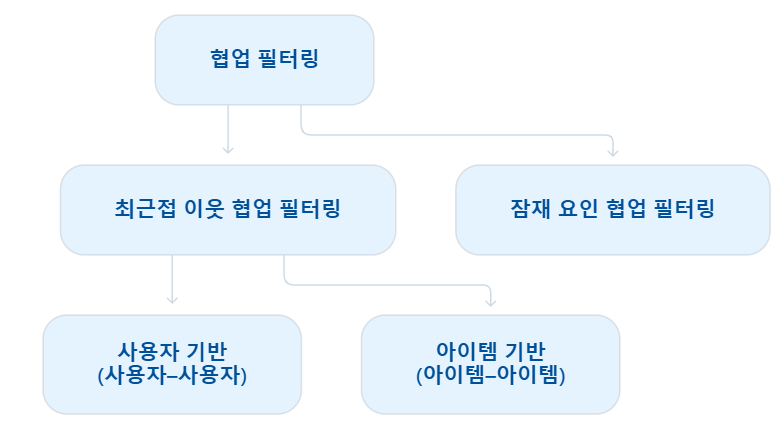